# Malaria Detection - EDA and Data Split

This notebook performs Exploratory Data Analysis (EDA) on the Malaria Cell Images dataset and splits it into training and testing sets.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split

%matplotlib inline

## 1. Load Data and EDA

In [2]:
# Define paths
data_dir = r'C:\Users\MECRUN\Desktop\Malaria\Malaria-Cell-Detection\Data'
parasitized_path = os.path.join(data_dir, 'Parasitized')
uninfected_path = os.path.join(data_dir, 'Uninfected')

# Get file lists
parasitized_files = glob.glob(os.path.join(parasitized_path, '*.png'))
uninfected_files = glob.glob(os.path.join(uninfected_path, '*.png'))

print(f"Parasitized images: {len(parasitized_files)}")
print(f"Uninfected images: {len(uninfected_files)}")
print(f"Total images: {len(parasitized_files) + len(uninfected_files)}")

Parasitized images: 13779
Uninfected images: 13779
Total images: 27558


In [3]:
# Create a DataFrame and add label
data = []
for p in parasitized_files:
    data.append({'path': p, 'label': 'Parasitized'})
for u in uninfected_files:
    data.append({'path': u, 'label': 'Uninfected'})

df = pd.DataFrame(data)
df.head()

,path,label
0,C:\Users\MECRUN\Desktop\Malaria\Malaria-Cell-D...,Parasitized
1,C:\Users\MECRUN\Desktop\Malaria\Malaria-Cell-D...,Parasitized
2,C:\Users\MECRUN\Desktop\Malaria\Malaria-Cell-D...,Parasitized
3,C:\Users\MECRUN\Desktop\Malaria\Malaria-Cell-D...,Parasitized
4,C:\Users\MECRUN\Desktop\Malaria\Malaria-Cell-D...,Parasitized


In [4]:
df.describe()

,path,label
count,27558,27558
unique,27558,2
top,C:\Users\MECRUN\Desktop\Malaria\Malaria-Cell-D...,Parasitized
freq,1,13779


In [5]:
df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27558 entries, 0 to 27557
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   path    27558 non-null  object
 1   label   27558 non-null  object
dtypes: object(2)
memory usage: 430.7+ KB


In [6]:
df.tail(2)

,path,label
27556,C:\Users\MECRUN\Desktop\Malaria\Malaria-Cell-D...,Uninfected
27557,C:\Users\MECRUN\Desktop\Malaria\Malaria-Cell-D...,Uninfected


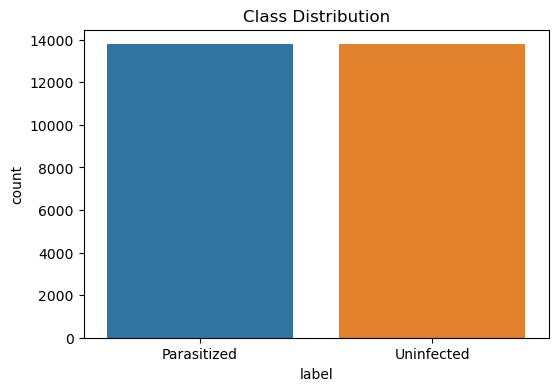

In [7]:
# Visualize Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df)
plt.title('Class Distribution')
plt.show()

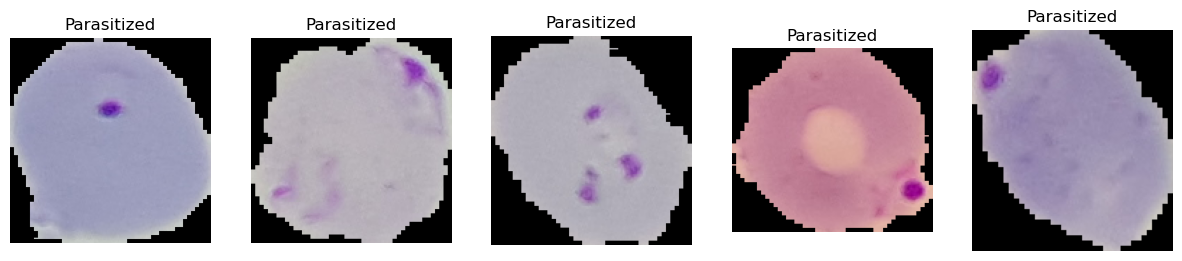

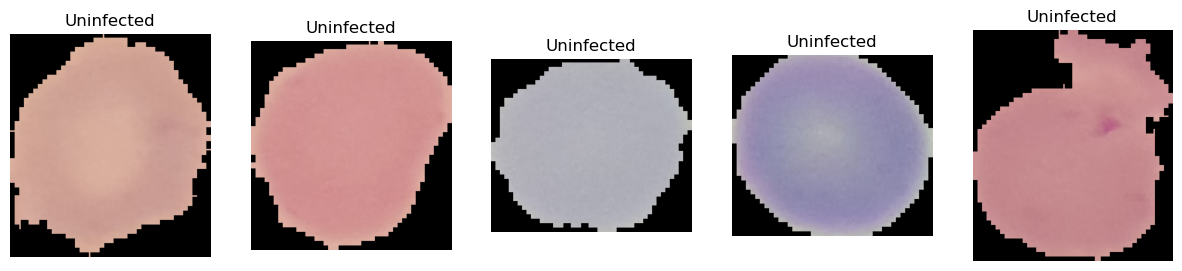

In [8]:
# Visualize Sample Images
def show_samples(label, num_samples=5):
    samples = df[df['label'] == label]['path'].sample(num_samples).values
    plt.figure(figsize=(15, 3))
    for i, img_path in enumerate(samples):
        img = Image.open(img_path)
        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)
        plt.title(label)
        plt.axis('off')
    plt.show()

show_samples('Parasitized')
show_samples('Uninfected')

## 2. Check Image Sizes

Average Width: 132.09
Average Height: 132.84


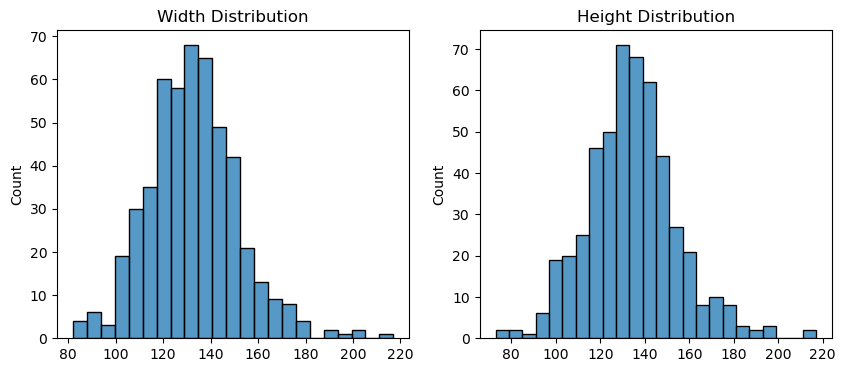

In [9]:
# Check dimensions of a few images
widths = []
heights = []

# Sample 500 images to check sizes (checking all might take time)
for img_path in df['path'].sample(500):
    img = Image.open(img_path)
    w, h = img.size
    widths.append(w)
    heights.append(h)

print(f"Average Width: {np.mean(widths):.2f}")
print(f"Average Height: {np.mean(heights):.2f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(widths)
plt.title('Width Distribution')
plt.subplot(1, 2, 2)
sns.histplot(heights)
plt.title('Height Distribution')
plt.show()

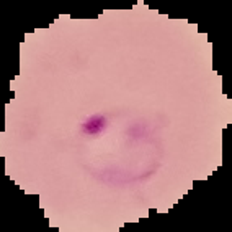

In [24]:
img = Image.open(df.path[0])
img.resize((232,232))

In [12]:
X = np.array(img.resize((224, 224)))
X.shape

(224, 224, 3)

## 3. Split Dataset

In [13]:
# Split into Train and Test (80% Train, 20% Test)
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

print(f"Train set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")

# Check distribution in splits
print("\nTrain Distribution:")
print(train_df['label'].value_counts())
print("\nTest Distribution:")
print(test_df['label'].value_counts())

Train set size: 22046
Test set size: 5512

Train Distribution:
label
Parasitized    11023
Uninfected     11023
Name: count, dtype: int64

Test Distribution:
label
Uninfected     2756
Parasitized    2756
Name: count, dtype: int64


In [22]:
train_df.columns

Index(['path', 'label'], dtype='object')

## 4. PyTorch Preparation

We will train a ResNet18 model using PyTorch.
First, we define a Custom Dataset class to load images from the file paths in our DataFrames.

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import models, transforms

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# Define Transforms
# ResNet expects 224x224 input resolution
train_transforms = transforms.Compose([
    transforms.Resize((232, 232)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # ImageNet normalization
])

test_transforms = transforms.Compose([
    transforms.Resize((232, 232)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


In [25]:
len(df)

27558

In [ ]:
class MalariaDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        self.label_map = {'Uninfected': 0, 'Parasitized': 1}
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['path']
        label_str = row['label']
        
        image = Image.open(img_path).convert('RGB')
        label = self.label_map[label_str]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label


In [ ]:
# Create Datasets
train_dataset = MalariaDataset(train_df, transform=train_transforms)
test_dataset = MalariaDataset(test_df, transform=test_transforms)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

## 5. Model Training

In [ ]:
# Load Pre-trained ResNet18
model = models.resnet18(pretrained=True)

# Freeze early layers (optional, but speeds up training and good for small datasets)
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer
# ResNet18 last layer is 'fc': Linear(in_features=512, out_features=1000)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2) # 2 output classes

model = model.to(device)

# Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [ ]:
def train_model(model, criterion, optimizer, num_epochs=5):
    train_losses, test_losses = [], []
    train_accs, test_accs = [], []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)
        
        # Validation
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
        
        val_loss = val_loss / len(test_loader.dataset)
        val_acc = correct_val / total_val
        test_losses.append(val_loss)
        test_accs.append(val_acc)
        
        print(f'Epoch {epoch+1}/{num_epochs}: Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')
        
    return train_losses, test_losses, train_accs, test_accs

In [ ]:
# Train for 5 epochs (adjust as needed)
history = train_model(model, criterion, optimizer, num_epochs=3)

## 6. Evaluation

In [ ]:
# Plot Training Curves
train_losses, test_losses, train_accs, test_accs = history

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Val Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(test_accs, label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.show()